# Lab 6: Simple Linear Regression
**Author:** 
**Date:** 2026-05-04

___

#### Topic Outline:

- Simple Linear Regression:
  - Motivating examples: a well-suited and a poorly-suited dataset.
  - Fitting a model using `statsmodels`.
  - Interpreting model output: coefficients, $R^2$, and hypothesis tests.
  - Visualising best fit lines, confidence intervals, and prediction intervals.
  - Making new predictions.
  - Residual analysis and model diagnostics.

---

#### Collaboration

You are encouraged to collaborate with other students in your labs, but you are expected to write up your own work for submission.  Please do not copy and paste other people's solutions to problems as it is considered plagiarism and you will be penalized and reported.  Should you choose to collaborate with others, please note their names here:

**Your name: Aldo Nunez** 

**Collaborators:**

1.

___

#### Agent Usage

Additionally, you are permitted to use resources such as ChatGPT and Claude to help you with your lab assignments and to enhance your learning experience.  Please make a note of any agents you have used in this submission here:

**Agents: Claude Code** 

---

## 1. Introduction

In Lab 5 we concluded our exploratory data analysis by identifying a strong positive linear relationship between `study_hours_per_week` and `final_score`.  This naturally raises the question: can we **model** this relationship formally and use it to make **predictions**?

**Simple Linear Regression (SLR)** is a statistical method for modelling the linear relationship between a single predictor variable $x$ and a continuous response variable $y$.  The model is:

$$Y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \overset{\text{iid}}{\sim} N(0,\, \sigma^2),$$

where:
- $\beta_0$ is the **intercept** — the expected value of $Y$ when $x = 0$.
- $\beta_1$ is the **slope** — the expected change in $Y$ for a one-unit increase in $x$.
- $\varepsilon_i$ are independent **errors** capturing variability not explained by $x$.

Given data $(x_1, y_1), \ldots, (x_n, y_n)$, we estimate $\beta_0$ and $\beta_1$ via **Ordinary Least Squares (OLS)**, which minimises the **Residual Sum of Squares**:

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2, \qquad \text{where} \quad \hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i.$$

In this lab we will:
1. Introduce two datasets — one well-suited to SLR and one that is not.
2. Fit SLR models using `statsmodels` and interpret the output.
3. Visualise best fit lines, confidence intervals, and prediction intervals.
4. Make predictions for new observations.
5. Perform residual analysis to assess model adequacy.

For this lab we will require the following packages:

In [1]:
# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot

# Seaborn style
sns.set_style("whitegrid")
sns.set_palette("Set2")

---

## 2. The Datasets

In this lab we shall consider two data sets. The first is our student performance data from last week which we have already inspected and is well-suited for SLR.  The second is a sythetic data set with a curved relationship that SLR cannot adequately capture.  We will compare the two side-by-side to make clear both the methodology and the limitations of the method.

### 2.1 Dataset 1: Student Performance

We load the `student_performance_cleaned.csv` data used in our previous 2 labs and isolate the predictor and response variables.

In [3]:
# Generate Dataset 1: Advertising -> Sales (linear relationship)
df1 = pd.read_csv('data/student_performance_cleaned.csv')
df1 = df1[['final_score', 'study_hours_per_week']]
df1.describe().round(2)

,final_score,study_hours_per_week
count,500.00,500.00
mean,55.98,15.31
std,15.37,8.57
min,20.00,2.00
25%,45.00,8.00
50%,56.00,15.00
75%,68.00,23.00
max,95.00,30.00


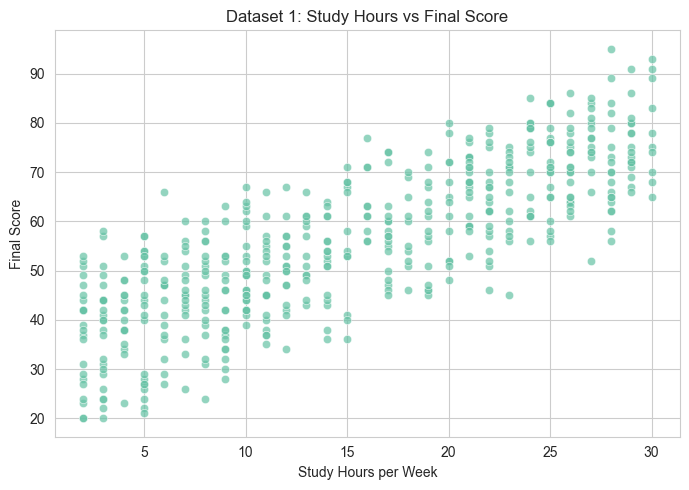

In [4]:
# Scatter plot of Dataset 1
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df1, x='study_hours_per_week', y='final_score', alpha=0.7)
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Score')
plt.title('Dataset 1: Study Hours vs Final Score')
plt.tight_layout()
plt.show()

### 2.2 Dataset 2: Temperature and Daily Energy Consumption

Our second dataset records the mean daily outside temperature (°C) and the daily electricity consumption (MWh) for a large residential district across a year.  Energy use tends to be **high in cold winters** (heating) and **high in hot summers** (air conditioning), producing a **U-shaped quadratic relationship** with temperature.  This non-linearity makes Dataset 2 a poor candidate for SLR.

In [5]:
# Generate Dataset 2: Temperature -> Energy consumption (curved relationship)
np.random.seed(7)
n2 = 200

temperature = np.random.uniform(-10, 40, n2)
energy = 350 + 0.6 * (temperature - 15) ** 2 + np.random.normal(0, 40, n2)

df2 = pd.DataFrame({'temperature': temperature, 'energy': energy})
df2.describe().round(2)

,temperature,energy
count,200.00,200.00
mean,14.47,470.00
std,14.24,117.08
min,-9.93,274.76
25%,3.09,380.40
50%,13.50,445.47
75%,27.07,548.67
max,39.63,823.74


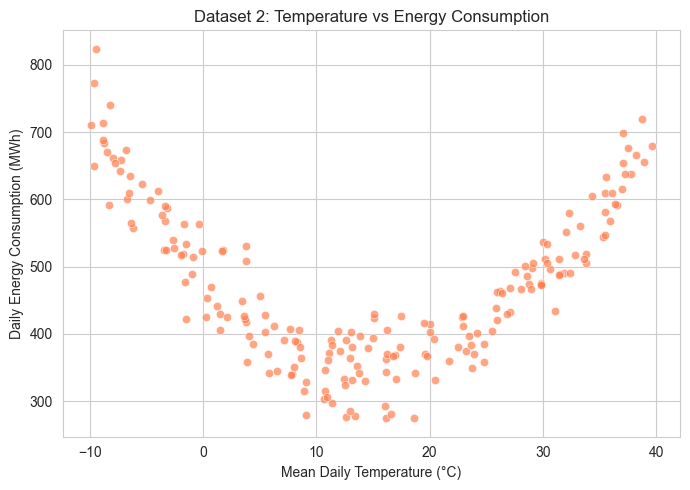

In [6]:
# Scatter plot of Dataset 2
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df2, x='temperature', y='energy', alpha=0.7, color='coral')
plt.xlabel('Mean Daily Temperature (°C)')
plt.ylabel('Daily Energy Consumption (MWh)')
plt.title('Dataset 2: Temperature vs Energy Consumption')
plt.tight_layout()
plt.show()

Notice that Dataset 1 displays a clear positive linear trend, whereas Dataset 2 exhibits a pronounced U-shaped (quadratic) pattern.  Keep this distinction in mind as we proceed — the curvature in Dataset 2 will cause systematic problems for SLR.

---

## 3. Fitting Simple Linear Regression Models

We fit SLR models using the `statsmodels` library, which provides rich output including coefficient estimates, standard errors, p-values, and fit statistics.  We use the **formula API** which allows us to specify models in a compact, readable way:

```python
model = smf.ols('response ~ predictor', data=df).fit()
```

The string `'response ~ predictor'` is a **model formula**: it says "regress `response` on `predictor`".  `statsmodels` automatically includes an intercept.  Calling `.fit()` computes the OLS estimates $\hat{\beta}_0$ and $\hat{\beta}_1$.

We fit the model $\text{sales} = \beta_0 + \beta_1 \cdot \text{advertising} + \varepsilon$ and inspect the output:

In [7]:
# Fit SLR model for Dataset 1
model1 = smf.ols('final_score ~ study_hours_per_week', data=df1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     909.8
Date:                Fri, 08 May 2026   Prob (F-statistic):          1.86e-114
Time:                        15:18:45   Log-Likelihood:                -1815.5
No. Observations:                 500   AIC:                             3635.
Df Residuals:                     498   BIC:                             3643.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               33.8935 

The key quantities to extract from the summary are:

| Field | Location in output | Interpretation |
|---|---|---|
| `coef` — `const` | Coefficients table | $\hat{\beta}_0$: predicted sales when advertising = 0 |
| `coef` — `advertising` | Coefficients table | $\hat{\beta}_1$: predicted change in sales per $\$1000$ increase in advertising |
| `P>\|t\|` | Both rows | p-value for testing whether each coefficient equals zero |
| `R-squared` | Top block | Proportion of variance in sales explained by advertising |
| `F-statistic` | Top block | Overall test that the model explains significant variation |

We see that our fitted model has estimates $\hat{\beta}_0=33.9$ - which is interpreted as the expected final score of a student who did not study for the course - and $\hat{\beta}_1=1.44$ - which gives the average score increase per hour per week studied.  Both parameter estimates have a negligible $p$-value which indicates they are both highly significant.  From $R^2=0.646$ we see that `study_hours_per_week` accounts for ~64% of the variance in `final_score`.  Furthermore, the negligible F-statistic probability indicates highly significant evidence that $\beta_1\neq 0$.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q1 Fitting a Model

Fit a model to our second data set and produce our model summary.  Discuss the parameter estimates, the p-values and the F test.  Is this model a good fit?

---
**Solution:**

In [8]:
model2 = smf.ols('temperature ~ energy', data=df2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            temperature   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.053
Date:                Fri, 08 May 2026   Prob (F-statistic):              0.306
Time:                        15:23:15   Log-Likelihood:                -813.92
No. Observations:                 200   AIC:                             1632.
Df Residuals:                     198   BIC:                             1638.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.6270      4.174      4.463      0.0

---

## 4. Best Fit Lines, Confidence Intervals, and Prediction Intervals

### 4.1 Confidence vs Prediction Intervals

After fitting, we can construct two types of interval at a new predictor value $x^*$:

**95% Confidence Interval (CI) for the mean response** — captures uncertainty about the true mean $E[Y \mid x^*] = \beta_0 + \beta_1 x^*$:

$$\hat{y}^* \;\pm\; t_{0.025,\, n-2} \cdot \hat{\sigma} \sqrt{\frac{1}{n} + \frac{(x^* - \bar{x})^2}{S_{xx}}}$$

**95% Prediction Interval (PI) for a new individual observation** — captures uncertainty about a single new $Y$ at $x^*$:

$$\hat{y}^* \;\pm\; t_{0.025,\, n-2} \cdot \hat{\sigma} \sqrt{1 + \frac{1}{n} + \frac{(x^* - \bar{x})^2}{S_{xx}}}$$

The PI is always **wider** than the CI because it accounts for both uncertainty in the regression line *and* the natural variability of a single new observation (the extra $1$ under the square root).

Both intervals **widen away from $\bar{x}$** — predictions near the centre of the data are more precise than those near the extremes, and extrapolating beyond the observed range becomes increasingly unreliable.

In `statsmodels`, both intervals are computed with a single call:

```python
pred = model.get_prediction(new_x_dataframe)
pred_df = pred.summary_frame(alpha=0.05)
# Columns: mean, mean_ci_lower, mean_ci_upper  (confidence interval)
#          obs_ci_lower, obs_ci_upper           (prediction interval)
```

For our student performance data we first produce a dense grid of x values with which we produce our best fit line using the function `get_prediction`.  From this we can reproduce our scatter plot with our best fit line and intervals overlayed.  The intervals can be visualized as shaded regions with `fill_between` which requires us to specify the upper and lower bound of the region.

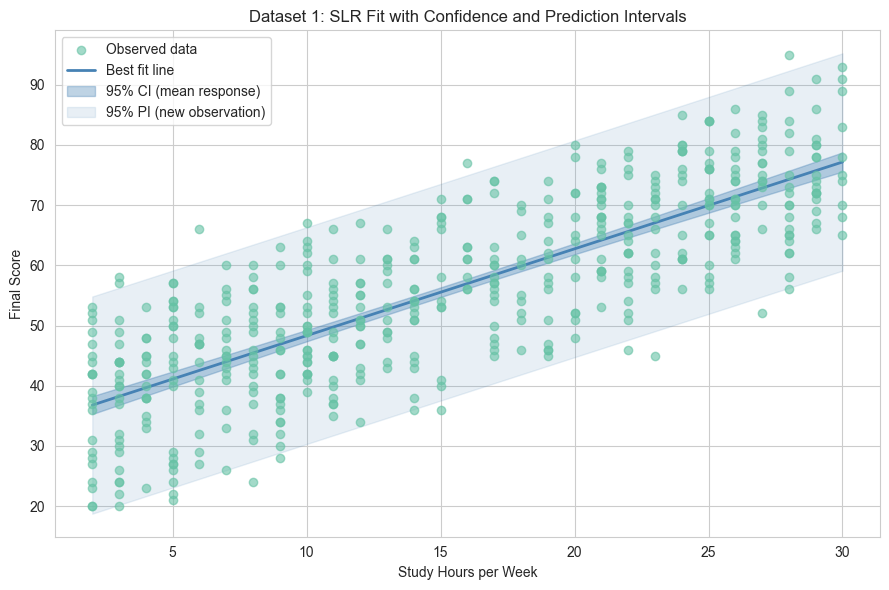

In [ ]:
# Dense grid of x values for smooth curves
x_grid1 = pd.DataFrame(
    {'study_hours_per_week': np.linspace(
        df1['study_hours_per_week'].min(), 
        df1['study_hours_per_week'].max(), 
        300)
        })

# Compute fitted values and intervals across the grid
pred1 = model1.get_prediction(x_grid1).summary_frame(alpha=0.05)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
# Plot the points
ax.scatter(
    df1['study_hours_per_week'], 
    df1['final_score'], 
    alpha=0.6, zorder=3, label='Observed data'
    )
# Plot the line
ax.plot(
    x_grid1['study_hours_per_week'], 
    pred1['mean'], 
    color='steelblue', lw=2, label='Best fit line')
# Plot the confidence and prediction intervals
ax.fill_between(
    x_grid1['study_hours_per_week'],
    pred1['mean_ci_lower'], pred1['mean_ci_upper'],
    alpha=0.35, color='steelblue', label='95% CI (mean response)'
)
ax.fill_between(
    x_grid1['study_hours_per_week'],
    pred1['obs_ci_lower'], pred1['obs_ci_upper'],
    alpha=0.12, color='steelblue', label='95% PI (new observation)'
)
ax.set_xlabel('Study Hours per Week')
ax.set_ylabel('Final Score')
ax.set_title('Dataset 1: SLR Fit with Confidence and Prediction Intervals')
ax.legend()
plt.tight_layout()
plt.show()

The best fit line closely tracks the data.  The confidence interval (darker shaded band) is narrow, reflecting high precision in estimating the mean response.  The prediction interval (lighter outer band) is wider, accommodating additional observation-level variability.  Notice that both bands are narrowest near the centre of the data and flare outward at the extremes.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2 Best Fit Line and Intervals

Repeat this procedure for our synthetic data set.  Comment on the differences you see in the with of the intervals and the path of the line through the points.  

---
**Solution:**

---

## 5. Making New Predictions

Once the model is fitted we can predict the response at **new** predictor values.  We pass a `DataFrame` with the same column name as the predictor used in the model formula.  The `.get_prediction().summary_frame()` call returns both point predictions and interval predictions in a single table.

In [31]:
# New student counts to predict test scores for
new_students = pd.DataFrame({'study_hours_per_week': [10, 15, 20, 25]})

# Full prediction summary: point estimate + CI + PI
pred_new1 = model1.get_prediction(new_students).summary_frame(alpha=0.05)
pred_new1.index = new_students['study_hours_per_week'].values
pred_new1.index.name = 'Study Hours per Week'

# Select and rename for readability
pred_new1 = pred_new1[['mean', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']]
pred_new1.columns = ['Final Score', 'CI Lower', 'CI Upper', 'PI Lower', 'PI Upper']
pred_new1.round(2)

,Final Score,CI Lower,CI Upper,PI Lower,PI Upper
Study Hours per Week,,,,,
10,48.32,47.37,49.26,30.31,66.33
15,55.53,54.73,56.33,37.53,73.53
20,62.74,61.83,63.66,44.74,80.75
25,69.95,68.74,71.17,51.93,87.98


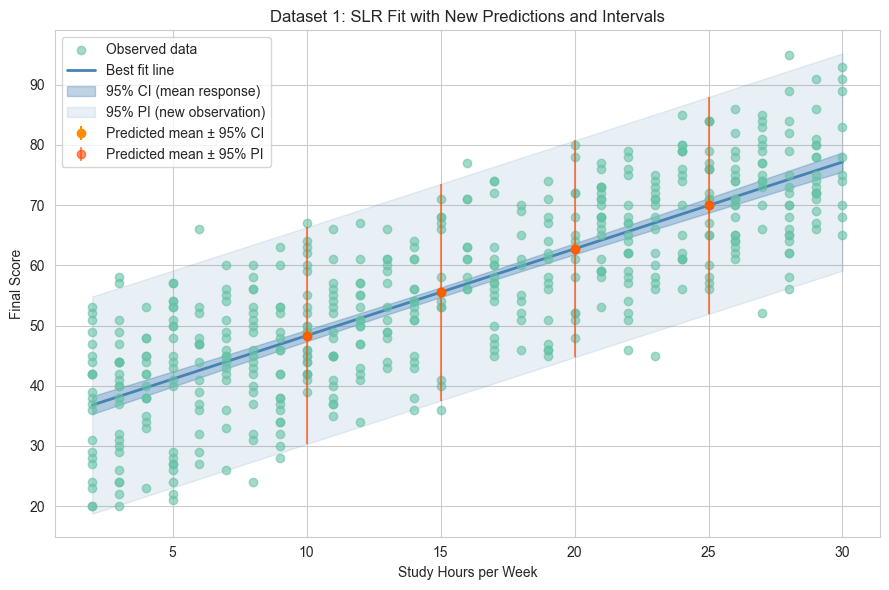

In [32]:
# Show new prediction on the scatter plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df1['study_hours_per_week'], df1['final_score'], alpha=0.6, zorder=3, label='Observed data')
ax.plot(x_grid1['study_hours_per_week'], pred1['mean'], color='steelblue', lw=2, label='Best fit line')
ax.fill_between(
    x_grid1['study_hours_per_week'],
    pred1['mean_ci_lower'], pred1['mean_ci_upper'],
    alpha=0.35, color='steelblue', label='95% CI (mean response)'
)
ax.fill_between(
    x_grid1['study_hours_per_week'],
    pred1['obs_ci_lower'], pred1['obs_ci_upper'],
    alpha=0.12, color='steelblue', label='95% PI (new observation)'
)
# Plot the new predictions with error bars
ax.errorbar(
    pred_new1.index, pred_new1['Final Score'], 
    yerr=[pred_new1['Final Score'] - pred_new1['CI Lower'], pred_new1['CI Upper'] - pred_new1['Final Score']],
    fmt='o', color='darkorange', label='Predicted mean ± 95% CI', zorder=4
)
ax.errorbar(
    pred_new1.index, pred_new1['Final Score'], 
    yerr=[pred_new1['Final Score'] - pred_new1['PI Lower'], pred_new1['PI Upper'] - pred_new1['Final Score']],
    fmt='o', color='orangered', alpha=0.6, label='Predicted mean ± 95% PI', zorder=4
)
ax.set_xlabel('Study Hours per Week')
ax.set_ylabel('Final Score')
ax.set_title('Dataset 1: SLR Fit with New Predictions and Intervals')
ax.legend()
plt.tight_layout()
plt.show()

The table shows for each study hours:
- **Final Score**: the point estimate $\hat{y}^* = \hat{\beta}_0 + \hat{\beta}_1 x^*$.
- **CI Lower / CI Upper**: the 95% CI for the *mean* final score across all students with those study hours.
- **PI Lower / PI Upper**: the 95% PI for a *single new* students final score with those study hours.

Observe that the PI is always wider than the CI.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3 Predictions

Repeat this process to compute predictions for our synthetic data set.  Comment on the accuracy of your predictions.  

---
**Solution:**

---

## 6. Residual Analysis

Fitting a model is only the first step — we must also **validate** that the model assumptions are satisfied.  The key assumptions of SLR are:

1. **Linearity**: the true relationship between $x$ and $y$ is linear.
2. **Independence**: the errors $\varepsilon_i$ are independent of each other.
3. **Homoscedasticity**: the errors have constant variance, $\text{Var}(\varepsilon_i) = \sigma^2$ for all $i$.
4. **Normality**: the errors follow a normal distribution.

We diagnose these assumptions by examining the **residuals** $e_i = y_i - \hat{y}_i$, which serve as estimates of the unknown errors $\varepsilon_i$.  The two standard diagnostic plots are:

**Residuals vs Fitted plot**: plots $e_i$ against $\hat{y}_i$.  A well-fitting model shows residuals scattered randomly around zero with no pattern.  A U-shaped or inverted-U pattern indicates non-linearity; a funnel shape indicates non-constant variance (heteroscedasticity).

**Normal Q-Q plot**: plots the quantiles of the residuals against the theoretical quantiles of the standard normal distribution.  If residuals are approximately normal the points should fall close to the diagonal reference line.  Systematic deviations suggest skewness or heavy tails.

We produce these diagnostic plots for our student performance data and comment on our observations.

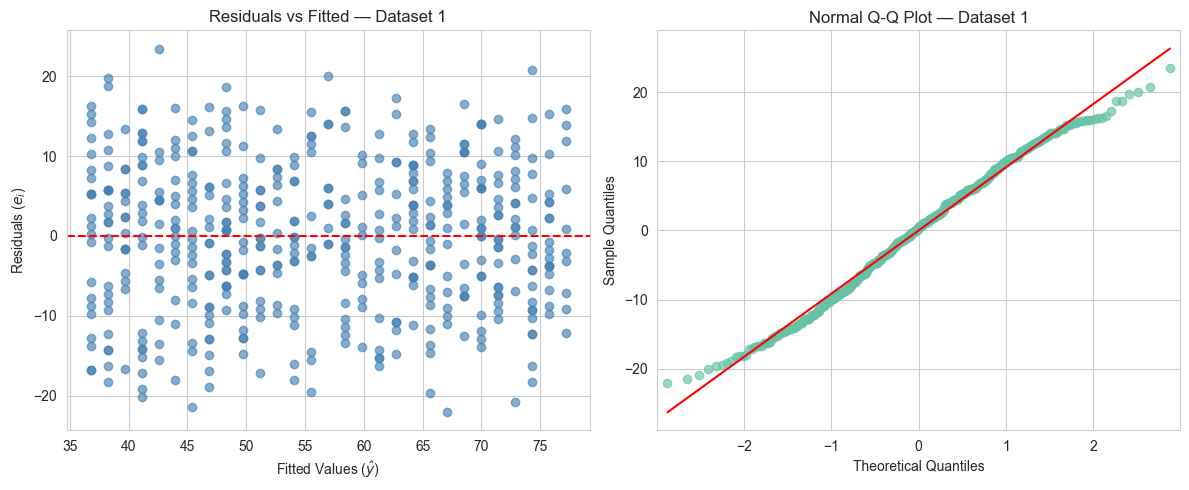

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Fitted
axes[0].scatter(model1.fittedvalues, model1.resid, alpha=0.65, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Fitted Values ($\\hat{y}$)')
axes[0].set_ylabel('Residuals ($e_i$)')
axes[0].set_title('Residuals vs Fitted — Dataset 1')

# Normal Q-Q plot
qqplot(model1.resid, line='s', ax=axes[1], alpha=0.65)
axes[1].set_title('Normal Q-Q Plot — Dataset 1')

plt.tight_layout()
plt.show()

For Dataset 1:
- **Residuals vs Fitted**: the residuals appear to scatter randomly around zero with no discernible pattern — consistent with linearity and homoscedasticity.
- **Q-Q plot**: the points follow the diagonal closely — consistent with normality.

Both plots support the conclusion that SLR is an appropriate model for Dataset 1.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q4 Residual Analysis

Reproduce these diagnostic plots for our synthetic data.  What patterns do you see in the residual analysis? Are the residuals Gaussian? 

---
**Solution:**

---

## Submission Checklist

- Ensure you have completed all problems in the notebook.
- Clear your document code outputs and rerun the notebook from top to bottom, checking for any new errors.
- At the top of your notebook click more options -> export -> pdf.
  - Alternatively, export to html and save as a pdf.
- Make sure your pdf has all code chunks clearly visible and executed.
- Submit before the posted deadline.